In [1]:
# ==========================================
# Trader Performance vs Market Sentiment
# Data Analytics Assignment
# Author: Rohan Verma
# ==========================================

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats

# Plot settings
plt.style.use("ggplot")
sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", None)

# Ignore warnings
import warnings
warnings.filterwarnings("ignore")

In [2]:
fear_df = pd.read_csv("fear_greed_index.csv")
trade_df = pd.read_csv("historical_data.csv")

In [3]:
fear_df.head()

,timestamp,value,classification,date
0,1517463000,30,Fear,2018-02-01
1,1517549400,15,Extreme Fear,2018-02-02
2,1517635800,40,Fear,2018-02-03
3,1517722200,24,Extreme Fear,2018-02-04
4,1517808600,11,Extreme Fear,2018-02-05


In [4]:
trade_df.head()

,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,02-12-2024 22:50,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,1.730000e+12
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,02-12-2024 22:50,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,1.730000e+12
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,02-12-2024 22:50,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,1.730000e+12
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,02-12-2024 22:50,1146.558564,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050043,1.080000e+15,1.730000e+12
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,02-12-2024 22:50,1289.488521,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.003055,1.050000e+15,1.730000e+12


In [5]:
fear_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2644 entries, 0 to 2643
Data columns (total 4 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   timestamp       2644 non-null   int64 
 1   value           2644 non-null   int64 
 2   classification  2644 non-null   object
 3   date            2644 non-null   object
dtypes: int64(2), object(2)
memory usage: 82.8+ KB


In [6]:
trade_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 107259 entries, 0 to 107258
Data columns (total 16 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Account           107259 non-null  object 
 1   Coin              107259 non-null  object 
 2   Execution Price   107259 non-null  float64
 3   Size Tokens       107259 non-null  float64
 4   Size USD          107259 non-null  float64
 5   Side              107259 non-null  object 
 6   Timestamp IST     107259 non-null  object 
 7   Start Position    107259 non-null  float64
 8   Direction         107259 non-null  object 
 9   Closed PnL        107259 non-null  float64
 10  Transaction Hash  107259 non-null  object 
 11  Order ID          107259 non-null  int64  
 12  Crossed           107259 non-null  bool   
 13  Fee               107259 non-null  float64
 14  Trade ID          107259 non-null  float64
 15  Timestamp         107259 non-null  float64
dtypes: bool(1), float64(

In [7]:
fear_df.describe(include='all')

,timestamp,value,classification,date
count,2.644000e+03,2644.000000,2644,2644
unique,NaN,NaN,5,2644
top,NaN,NaN,Fear,2025-05-02
freq,NaN,NaN,781,1
mean,1.631899e+09,46.981089,NaN,NaN
std,6.597967e+07,21.827680,NaN,NaN
min,1.517463e+09,5.000000,NaN,NaN
25%,1.574811e+09,28.000000,NaN,NaN
50%,1.631900e+09,46.000000,NaN,NaN
75%,1.688989e+09,66.000000,NaN,NaN


In [8]:
trade_df.describe(include='all')

,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp
count,107259,107259,107259.000000,1.072590e+05,1.072590e+05,107259,107259,1.072590e+05,107259,107259.000000,107259,1.072590e+05,107259,107259.000000,1.072590e+05,1.072590e+05
unique,17,217,NaN,NaN,NaN,2,11503,NaN,10,NaN,53294,NaN,2,NaN,NaN,NaN
top,0xbaaaf6571ab7d571043ff1e313a9609a10637864,HYPE,NaN,NaN,NaN,BUY,14-02-2025 00:31,NaN,Open Long,NaN,0x00000000000000000000000000000000000000000000...,NaN,True,NaN,NaN,NaN
freq,21192,39372,NaN,NaN,NaN,54375,441,NaN,32884,NaN,4398,NaN,56855,NaN,NaN,NaN
mean,NaN,NaN,17433.652966,6.515467e+03,7.726220e+03,NaN,NaN,2.274568e+04,NaN,71.380360,NaN,6.643196e+10,NaN,1.536158,5.629039e+14,1.736486e+12
std,NaN,NaN,35097.683407,1.423834e+05,4.831285e+04,NaN,NaN,4.510277e+05,NaN,1135.038257,NaN,2.217174e+10,NaN,8.483012,3.264590e+14,1.187186e+10
min,NaN,NaN,0.000005,5.330000e-06,0.000000e+00,NaN,NaN,-1.433463e+07,NaN,-117990.104100,NaN,1.732711e+08,NaN,-1.175712,0.000000e+00,1.000000e+00
25%,NaN,NaN,12.291000,9.559050e-01,2.096400e+02,NaN,NaN,-2.354860e+00,NaN,0.000000,NaN,5.730408e+10,NaN,0.010987,2.800000e+14,1.730000e+12
50%,NaN,NaN,21.169000,2.138000e+01,7.498300e+02,NaN,NaN,1.218893e+02,NaN,0.000000,NaN,7.350572e+10,NaN,0.084806,5.620000e+14,1.740000e+12
75%,NaN,NaN,2376.400000,1.393350e+02,2.793525e+03,NaN,NaN,1.654681e+04,NaN,7.476000,NaN,8.116363e+10,NaN,0.497734,8.470000e+14,1.740000e+12


In [9]:
fear_df.isnull().sum()

,0
timestamp,0
value,0
classification,0
date,0


In [10]:
trade_df.isnull().sum()

,0
Account,0
Coin,0
Execution Price,0
Size Tokens,0
Size USD,0
Side,0
Timestamp IST,0
Start Position,0
Direction,0
Closed PnL,0


In [11]:
fear_df.duplicated().sum()

np.int64(0)

In [12]:
trade_df.duplicated().sum()

np.int64(0)

# Data Cleaning

In [14]:
#Convert Fear & Greed Date
fear_df["date"] = pd.to_datetime(fear_df["date"])

In [17]:
#Convert Timestamp
trade_df["time"] = pd.to_datetime(
    trade_df["Timestamp"],
    unit="ms",
    errors="coerce"
)

In [19]:
#Create Merge Date
trade_df["TradeDate"] = trade_df["time"].dt.date
fear_df["TradeDate"] = fear_df["date"].dt.date

In [20]:
# Merging on TradeDate

df = trade_df.merge(
    fear_df,
    on="TradeDate",
    how="left"
)

In [22]:
print(df.shape)

df["classification"].value_counts(dropna=False)

(107259, 22)


,count
classification,
Fear,65885
NaN,14014
Greed,13301
Neutral,7097
Extreme Greed,6962


# Feature Engineering

In [23]:

df["Trade Outcome"] = np.where(
    df["Closed PnL"] > 0,
    "Profit",
    "Loss"
)

In [24]:
df["Win"] = (df["Closed PnL"] > 0).astype(int)

In [25]:
df["Hour"] = df["time"].dt.hour

In [26]:
df["Weekday"] = df["time"].dt.day_name()

In [27]:
df["Month"] = df["time"].dt.month_name()

In [28]:
df["Abs PnL"] = df["Closed PnL"].abs()

In [34]:
sentiment_counts = (
    fear_df["classification"]
    .value_counts()
)

sentiment_counts

,count
classification,
Fear,781
Greed,633
Extreme Fear,508
Neutral,396
Extreme Greed,326


# EDA

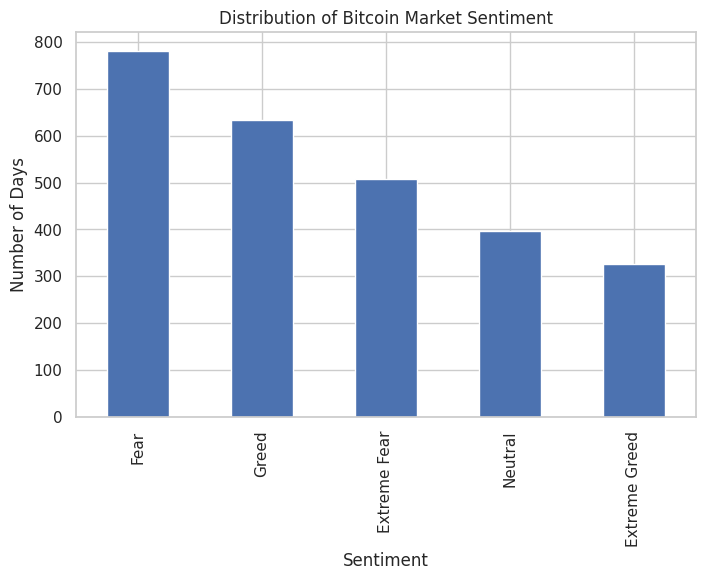

In [35]:
plt.figure(figsize=(8,5))

sentiment_counts.plot(kind="bar")

plt.title("Distribution of Bitcoin Market Sentiment")
plt.xlabel("Sentiment")
plt.ylabel("Number of Days")

plt.show()

In [36]:
trade_counts = (
    df.groupby("classification")
      .size()
      .sort_values()
)

trade_counts

,0
classification,
Extreme Greed,6962
Neutral,7097
Greed,13301
Fear,65885


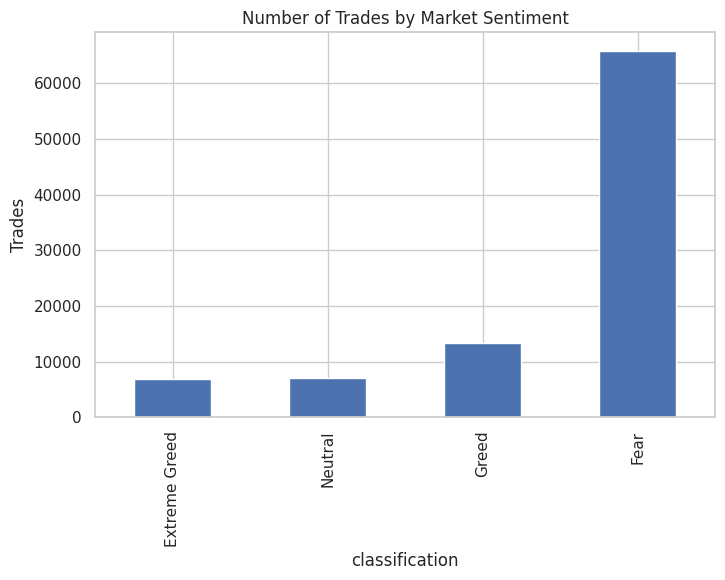

In [37]:
plt.figure(figsize=(8,5))

trade_counts.plot(kind="bar")

plt.title("Number of Trades by Market Sentiment")

plt.ylabel("Trades")

plt.show()

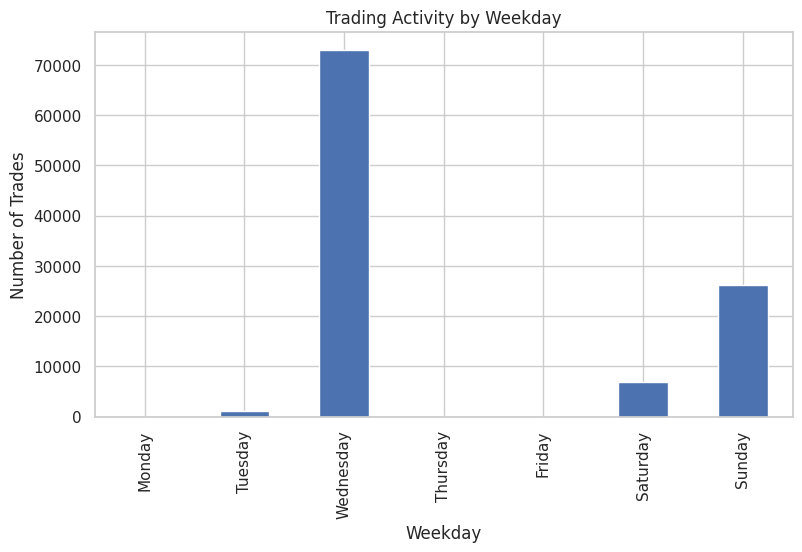

In [49]:
weekday_order = [
    "Monday",
    "Tuesday",
    "Wednesday",
    "Thursday",
    "Friday",
    "Saturday",
    "Sunday"
]

weekday_trades = (
    df["Weekday"]
      .value_counts()
      .reindex(weekday_order)
)

plt.figure(figsize=(9,5))

weekday_trades.plot(kind="bar")

plt.title("Trading Activity by Weekday")
plt.xlabel("Weekday")
plt.ylabel("Number of Trades")

plt.show()

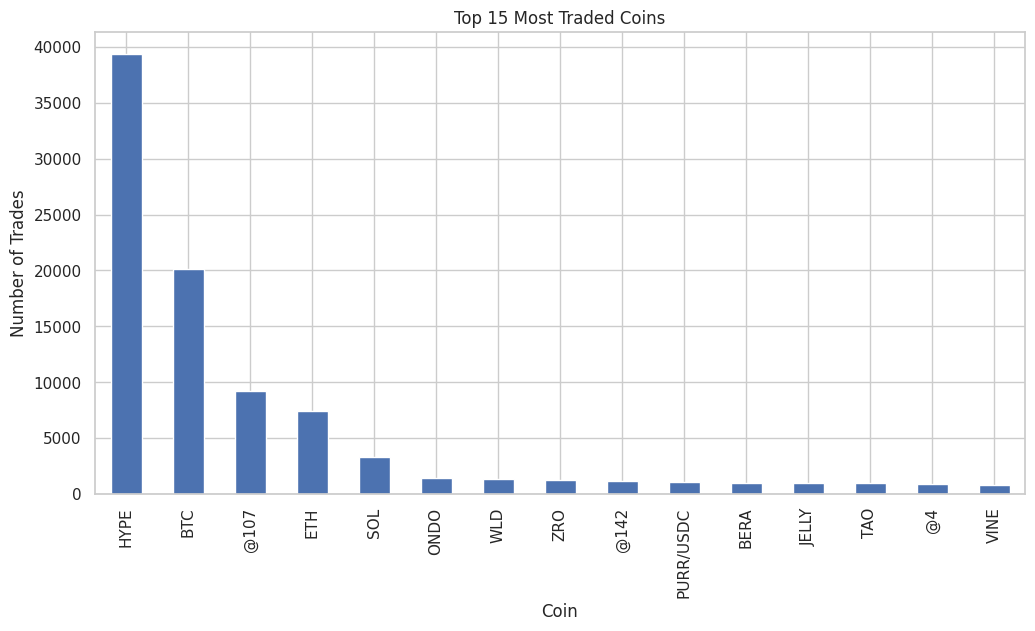

In [50]:
top_coins = (
    df["Coin"]
      .value_counts()
      .head(15)
)

plt.figure(figsize=(12,6))

top_coins.plot(kind="bar")

plt.title("Top 15 Most Traded Coins")
plt.xlabel("Coin")
plt.ylabel("Number of Trades")

plt.show()

In [42]:
median_pnl = (
    df.groupby("classification")["Closed PnL"]
      .median()
)

median_pnl

,Closed PnL
classification,
Extreme Greed,0.0
Fear,0.0
Greed,0.0
Neutral,0.0


In [47]:
df["Closed PnL"].value_counts().head(20)

,count
Closed PnL,
0.000000,56264
0.146908,80
9.903600,67
88.459120,62
0.095175,50
0.066620,50
1.149000,46
1.955000,45
3.766400,41


In [51]:
realized_df = df[df["Closed PnL"] != 0].copy()

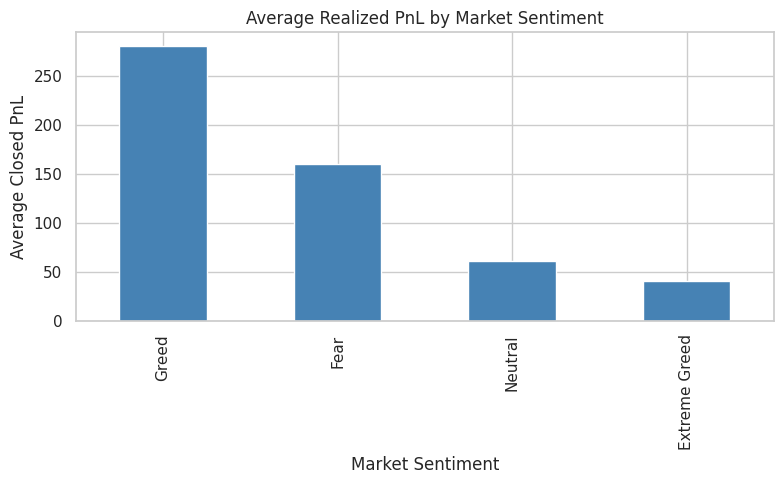

In [53]:
avg_pnl = (
    realized_df
    .groupby("classification")["Closed PnL"]
    .mean()
    .sort_values(ascending=False)
)

plt.figure(figsize=(8,5))

avg_pnl.plot(
    kind="bar",
    color="steelblue"
)

plt.title("Average Realized PnL by Market Sentiment")
plt.xlabel("Market Sentiment")
plt.ylabel("Average Closed PnL")

plt.tight_layout()
plt.show()

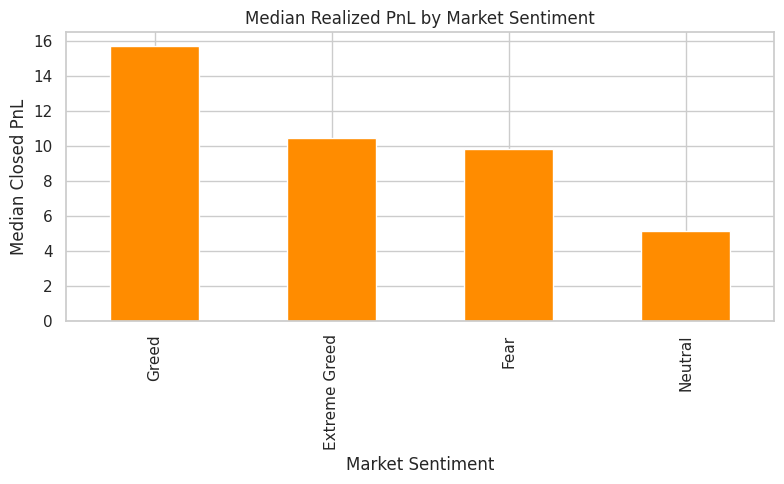

In [55]:
median_pnl = (
    realized_df
    .groupby("classification")["Closed PnL"]
    .median()
    .sort_values(ascending=False)
)

plt.figure(figsize=(8,5))

median_pnl.plot(
    kind="bar",
    color="darkorange"
)

plt.title("Median Realized PnL by Market Sentiment")
plt.xlabel("Market Sentiment")
plt.ylabel("Median Closed PnL")

plt.tight_layout()
plt.show()

In [56]:
realized_df["Win"].describe()

,Win
count,50995.000000
mean,0.895774
std,0.305556
min,0.000000
25%,1.000000
50%,1.000000
75%,1.000000
max,1.000000


In [57]:
win_rate = (
    realized_df
    .groupby("classification")["Win"]
    .mean()
    * 100
)

win_rate

,Win
classification,
Extreme Greed,78.762696
Fear,93.103336
Greed,87.681393
Neutral,80.777461


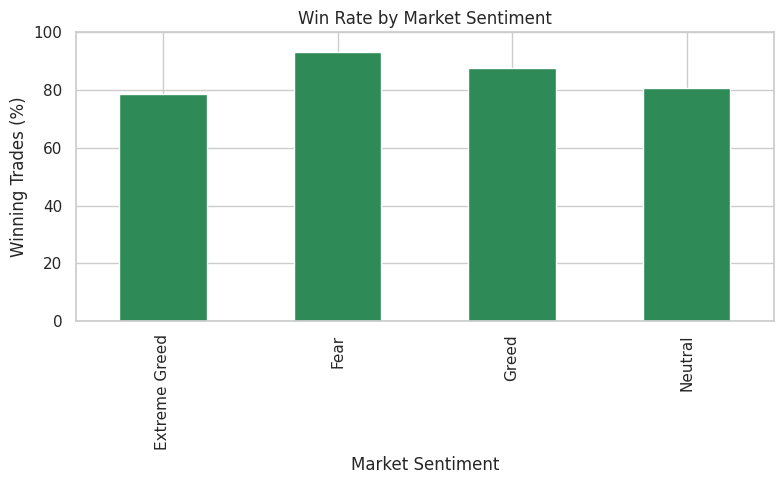

In [58]:
plt.figure(figsize=(8,5))

win_rate.plot(
    kind="bar",
    color="seagreen"
)

plt.title("Win Rate by Market Sentiment")
plt.ylabel("Winning Trades (%)")
plt.xlabel("Market Sentiment")

plt.ylim(0,100)

plt.tight_layout()
plt.show()

In [66]:
upper = realized_df["Closed PnL"].quantile(0.99)
lower = realized_df["Closed PnL"].quantile(0.01)

filtered_box = realized_df[
    (realized_df["Closed PnL"] >= lower) &
    (realized_df["Closed PnL"] <= upper)
]

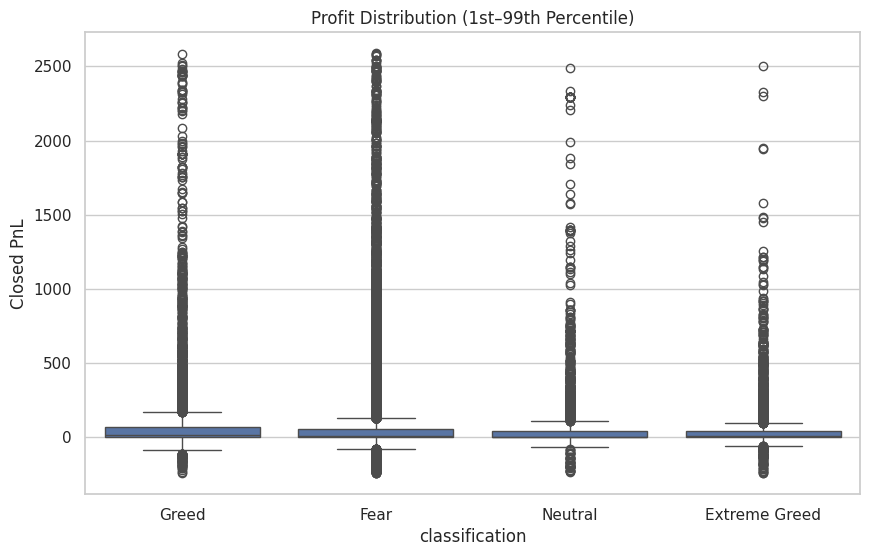

In [68]:
plt.figure(figsize=(10,6))

sns.boxplot(
    data=filtered_box,
    x="classification",
    y="Closed PnL"
)

plt.title("Profit Distribution (1st–99th Percentile)")

plt.show()

In [81]:
top5 = (
    realized_df["Coin"]
    .value_counts()
    .head(5)
    .index
)

heatmap_df = realized_df[
    realized_df["Coin"].isin(top5)
]

In [82]:
pivot = (
    heatmap_df
    .pivot_table(
        index="Coin",
        columns="classification",
        values="Closed PnL",
        aggfunc="median"
    )
)

In [83]:
count_pivot = (
    heatmap_df
    .pivot_table(
        index="Coin",
        columns="classification",
        values="Closed PnL",
        aggfunc="count"
    )
)

count_pivot

classification,Extreme Greed,Fear,Greed,Neutral
Coin,,,,
@107,NaN,2459.0,1180.0,NaN
BTC,684.0,4174.0,790.0,89.0
ETH,860.0,1380.0,365.0,644.0
HYPE,NaN,15270.0,1909.0,NaN
SOL,14.0,543.0,69.0,56.0


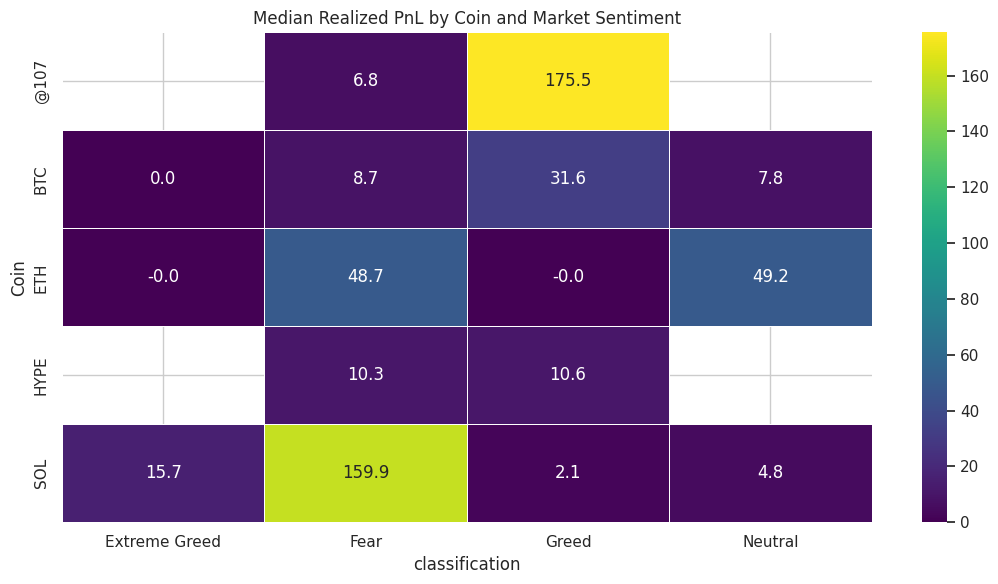

In [85]:
plt.figure(figsize=(11,6))

sns.heatmap(
    pivot,
    annot=True,
    fmt=".1f",
    cmap="viridis",
    linewidths=.5
)

plt.title("Median Realized PnL by Coin and Market Sentiment")

plt.tight_layout()

plt.show()

In [70]:
summary = realized_df.groupby("classification").agg(
    Trades=("Closed PnL", "count"),
    Avg_PnL=("Closed PnL", "mean"),
    Median_PnL=("Closed PnL", "median"),
    Total_PnL=("Closed PnL", "sum"),
    Win_Rate=("Win", "mean")
)

summary["Win_Rate"] *= 100
summary = summary.round(2)

summary

,Trades,Avg_PnL,Median_PnL,Total_PnL,Win_Rate
classification,,,,,
Extreme Greed,4332,40.85,10.48,176965.49,78.76
Fear,30754,160.25,9.84,4928444.20,93.10
Greed,6202,280.67,15.70,1740744.38,87.68
Neutral,2804,61.79,5.14,173248.88,80.78


In [86]:
realized_df["Side"].value_counts()

,count
Side,
SELL,36362
BUY,14633


In [87]:
side_sentiment = (
    realized_df
    .groupby(["classification", "Side"])["Closed PnL"]
    .mean()
    .unstack()
)

side_sentiment

Side,BUY,SELL
classification,,
Extreme Greed,44.630093,37.808397
Fear,401.027823,80.918647
Greed,-104.853849,422.621983
Neutral,30.483940,117.819181


<Figure size 1000x600 with 0 Axes>

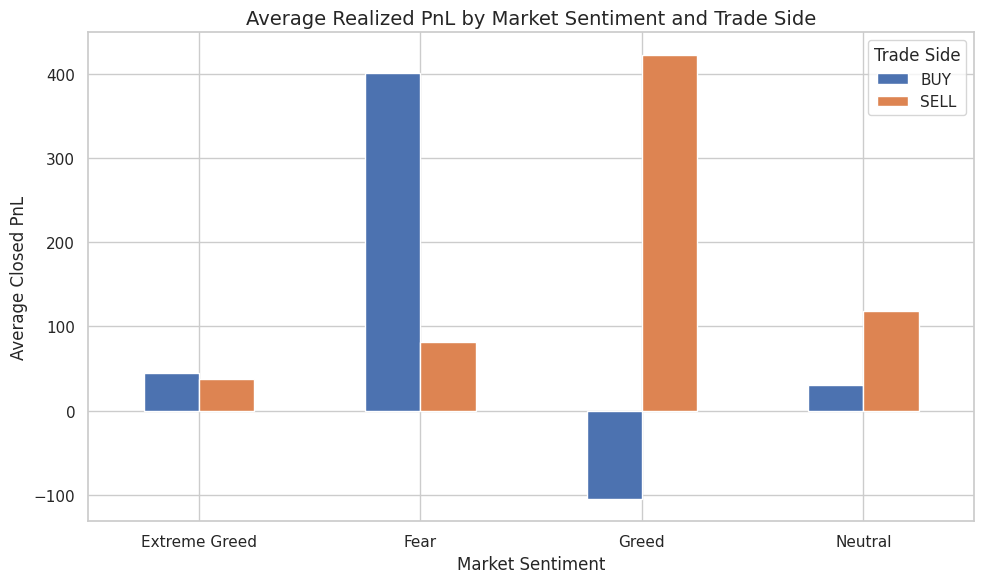

In [88]:
plt.figure(figsize=(10,6))

side_sentiment.plot(
    kind="bar",
    figsize=(10,6),
    color=["#4C72B0", "#DD8452"]
)

plt.title("Average Realized PnL by Market Sentiment and Trade Side", fontsize=14)
plt.xlabel("Market Sentiment")
plt.ylabel("Average Closed PnL")
plt.xticks(rotation=0)
plt.legend(title="Trade Side")

plt.tight_layout()
plt.show()

In [89]:
median_side = (
    realized_df
    .groupby(["classification", "Side"])["Closed PnL"]
    .median()
    .unstack()
)

median_side

Side,BUY,SELL
classification,,
Extreme Greed,6.497990,12.734393
Fear,25.066488,6.951840
Greed,5.694186,21.376635
Neutral,2.497014,36.091008


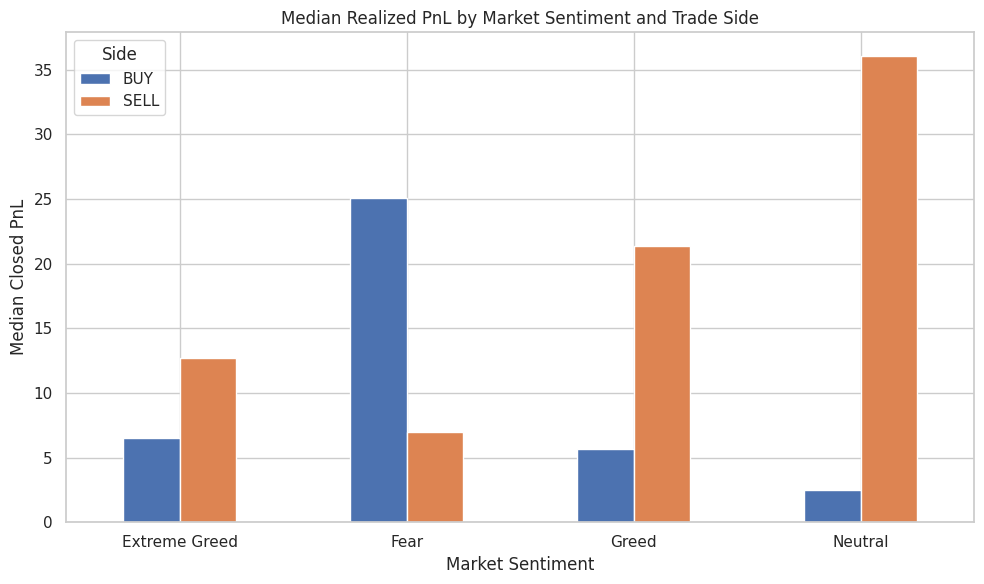

In [90]:
median_side.plot(
    kind="bar",
    figsize=(10,6),
    color=["#4C72B0", "#DD8452"]
)

plt.title("Median Realized PnL by Market Sentiment and Trade Side")
plt.ylabel("Median Closed PnL")
plt.xlabel("Market Sentiment")
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

In [91]:
side_win = (
    realized_df
    .groupby(["classification", "Side"])["Win"]
    .mean()
    .mul(100)
    .unstack()
)

side_win

Side,BUY,SELL
classification,,
Extreme Greed,79.710145,78.000000
Fear,91.327736,93.688397
Greed,80.047933,90.491948
Neutral,76.097832,89.154229


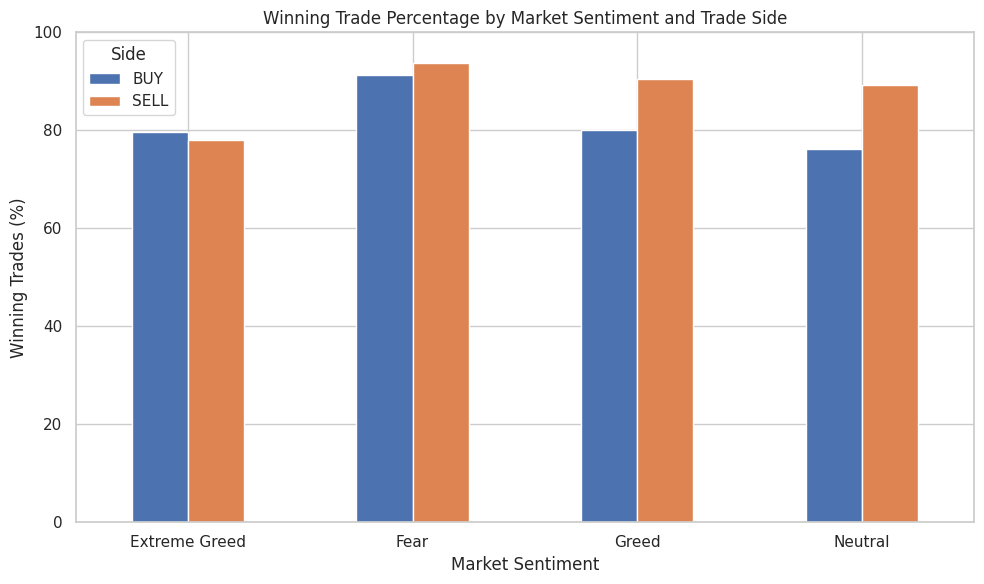

In [92]:
side_win.plot(
    kind="bar",
    figsize=(10,6),
    color=["#4C72B0", "#DD8452"]
)

plt.title("Winning Trade Percentage by Market Sentiment and Trade Side")
plt.ylabel("Winning Trades (%)")
plt.xlabel("Market Sentiment")
plt.xticks(rotation=0)
plt.ylim(0,100)

plt.tight_layout()
plt.show()

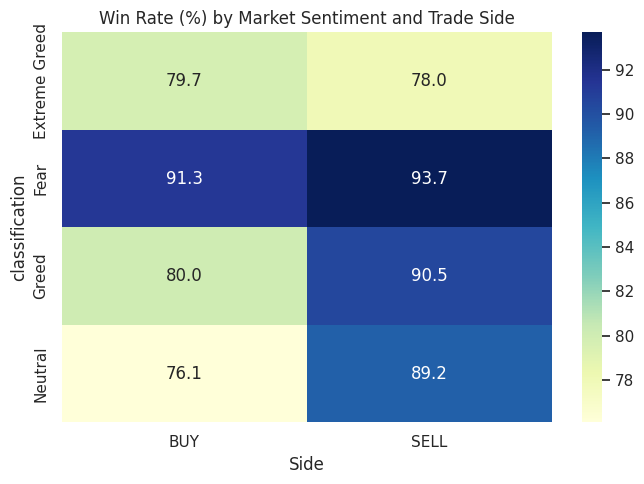

In [93]:
plt.figure(figsize=(7,5))

sns.heatmap(
    side_win,
    annot=True,
    fmt=".1f",
    cmap="YlGnBu"
)

plt.title("Win Rate (%) by Market Sentiment and Trade Side")

plt.tight_layout()
plt.show()